# Agentic and Explainable Machine Learning for Small-Molecule Drug Design

**Portfolio notebook for AI for Drug Discovery, Small Molecule Drug Design**

**Author:** Mark I. R. Petalcorin, PhD

This notebook is a runnable, portfolio-style demonstration of small-molecule drug-design machine learning. It simulates realistic discovery datasets, trains predictive models, explains model decisions, estimates uncertainty, and adds an agentic decision-support layer for medicinal chemistry triage.

## What this notebook demonstrates

1. Simulated, benchmarked molecular and protein–ligand datasets.
2. Structure-aware features for binding-affinity prediction.
3. Active versus inactive compound classification.
4. Continuous pIC50 regression.
5. Global and local explainable AI.
6. Uncertainty and applicability-domain analysis.
7. Multi-objective lead prioritisation.
8. Agentic AI modules for data audit, explanation, active learning, and medicinal chemistry triage.

## PubMed-indexed references used to benchmark simulated ranges

- Lipinski CA et al. *Advanced Drug Delivery Reviews*. 2001. PMID: 11259830.
- Veber DF et al. *Journal of Medicinal Chemistry*. 2002. PMID: 12036371.
- Rogers D, Hahn M. *Journal of Chemical Information and Modeling*. 2010. PMID: 20426451.
- Liu T et al. *Nucleic Acids Research*. 2007. PMID: 17145705.
- Ballester PJ, Mitchell JBO. *Bioinformatics*. 2010. PMID: 20236947.
- Wu Z et al. *Chemical Science*. 2018. PMID: 29629118.
- Kearnes S et al. *Journal of Computer-Aided Molecular Design*. 2016. PMID: 27558503.
- Torng W, Altman RB. *Journal of Chemical Information and Modeling*. 2019. PMID: 31580672.
- Heid E et al. *Journal of Chemical Information and Modeling*. 2024. PMID: 38147829.
- Lundberg SM et al. *Nature Biomedical Engineering*. 2018. PMID: 31001455.

**Important:** This notebook uses simulated data only. It does not use proprietary Roche data, real patient data, or confidential assay data.

In [56]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
import math
import textwrap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_score, learning_curve
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    roc_auc_score, average_precision_score, accuracy_score, f1_score,
    precision_score, recall_score, confusion_matrix,
    RocCurveDisplay, PrecisionRecallDisplay,
    mean_absolute_error, mean_squared_error, r2_score
)
from sklearn.inspection import permutation_importance, PartialDependenceDisplay
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression, Ridge
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor, GradientBoostingClassifier, GradientBoostingRegressor, IsolationForest
from sklearn.neural_network import MLPClassifier, MLPRegressor
from sklearn.calibration import calibration_curve
from sklearn.cluster import KMeans

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

FIG_DIR = Path("figures_ai4dd")
FIG_DIR.mkdir(exist_ok=True)

def savefig(name):
    path = FIG_DIR / name
    plt.tight_layout()
    plt.savefig(path, dpi=220, bbox_inches="tight")
    print("Saved:", path)

print("Environment ready.")

Environment ready.


# 1. Simulate a benchmarked small-molecule discovery dataset

The simulation includes molecular descriptors, protein–ligand interaction features, graph-inspired latent descriptors, docking-like scores, ADME-like readouts, potency labels, and multi-objective lead scores.

The simulated values are constrained to biologically and chemically plausible ranges, for example:

- pIC50 and pKd values are generated across weak micromolar to nanomolar-like ranges.
- Molecular weight, cLogP, hydrogen-bond donors and acceptors, TPSA, and rotatable bonds follow drug-like medicinal chemistry ranges.
- Docking-like scores and protein–ligand contacts are simulated to correlate imperfectly with potency, as expected in real-world drug discovery.

In [59]:
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def clipped_normal(mean, sd, low, high, size):
    return np.clip(np.random.normal(mean, sd, size), low, high)

def simulate_ai4dd_dataset(n=2400, random_state=42):
    rng = np.random.default_rng(random_state)

    targets = np.array(["LDHA", "ATR", "RAD52", "POLQ", "KRAS_G12D", "PI3K_alpha"])
    family = {
        "LDHA": "metabolic_enzyme",
        "ATR": "kinase",
        "RAD52": "DNA_repair",
        "POLQ": "DNA_repair_polymerase",
        "KRAS_G12D": "small_GTPase",
        "PI3K_alpha": "kinase"
    }
    target = rng.choice(targets, size=n, p=[0.20, 0.18, 0.16, 0.18, 0.12, 0.16])
    target_family = np.array([family[t] for t in target])

    MW = clipped_normal(390, 85, 180, 720, n)
    cLogP = clipped_normal(3.0, 1.25, -1.5, 7.5, n)
    HBD = rng.poisson(1.4, n).clip(0, 7)
    HBA = rng.poisson(5.2, n).clip(0, 14)
    TPSA = np.clip(18 + HBA * 8.5 + HBD * 11 + rng.normal(0, 18, n), 15, 210)
    rotB = rng.poisson(5.5, n).clip(0, 18)
    aromatic = rng.poisson(2.0, n).clip(0, 7)
    fsp3 = np.clip(rng.beta(2.2, 3.5, n), 0.02, 0.95)

    hydrophobic = np.clip(np.round(2 + 1.4*aromatic + 0.55*cLogP + rng.normal(0, 1.6, n)), 0, 16)
    hbonds = np.clip(np.round(0.45*HBD + 0.28*HBA + rng.normal(0, 1.2, n)), 0, 9)
    electrostatic = np.clip(np.round(0.09*TPSA + rng.normal(0, 2.0, n)), 0, 16)
    pi_stacking = np.clip(np.round(0.9*aromatic + rng.normal(0, 1.0, n)), 0, 8)
    salt_bridges = np.clip(np.round(0.07*TPSA + rng.normal(-2.5, 1.4, n)), 0, 5)
    shape = np.clip(rng.normal(0.62, 0.13, n) + 0.05*np.log1p(aromatic) - 0.03*np.abs(cLogP-3), 0.20, 0.96)
    buried_area = np.clip(230 + 9.5*MW + 45*shape + rng.normal(0, 160, n), 500, 5600)

    target_effect = {"LDHA": 0.25, "ATR": 0.45, "RAD52": 0.10, "POLQ": 0.25, "KRAS_G12D": -0.15, "PI3K_alpha": 0.35}
    te = np.array([target_effect[t] for t in target])

    docking = (
        -4.0 - 0.18*hydrophobic - 0.32*hbonds - 0.12*pi_stacking
        - 1.15*shape - 0.00035*buried_area
        + 0.18*np.abs(cLogP-3.2) + 0.012*np.maximum(TPSA-130, 0)
        + rng.normal(0, 0.9, n)
    )
    docking = np.clip(docking, -14.5, -2.0)

    graph_1 = np.clip(0.55*fsp3 + 0.06*rotB - 0.04*aromatic + rng.normal(0, 0.2, n), -1.5, 2.5)
    graph_2 = np.clip(0.018*TPSA - 0.25*HBD + rng.normal(0, 0.4, n), -2.5, 3.5)
    graph_3 = np.clip(0.20*aromatic + 0.11*cLogP + rng.normal(0, 0.35, n), -1.2, 3.0)
    graph_4 = np.clip(0.003*MW - 0.09*rotB + rng.normal(0, 0.25, n), -1.5, 2.5)
    graph_5 = np.clip(0.2*shape + 0.04*hbonds + rng.normal(0, 0.25, n), -1.0, 2.2)

    pKd = (
        4.9 + 0.33*(-docking - 6) + 0.09*hydrophobic + 0.13*hbonds
        + 0.08*pi_stacking + 1.05*shape + te
        - 0.015*np.maximum(TPSA-120, 0) - 0.08*np.maximum(cLogP-5, 0)
        + 0.25*graph_5 + rng.normal(0, 0.50, n)
    )
    pKd = np.clip(pKd, 3.8, 10.3)
    pIC50 = np.clip(pKd + rng.normal(0.0, 0.35, n) - 0.10*np.maximum(rotB-10, 0), 3.5, 10.5)

    logS = np.clip(-0.5 - 0.55*cLogP - 0.0025*MW + 0.008*TPSA + rng.normal(0, 0.45, n), -7.5, 1.5)
    permeability = np.clip(0.70 + 0.10*cLogP - 0.0045*TPSA - 0.025*HBD + rng.normal(0, 0.12, n), 0.02, 0.98)
    clearance_risk = np.clip(sigmoid(-2.2 + 0.43*cLogP + 0.004*MW + 0.12*aromatic + rng.normal(0, 0.9, n)), 0, 1)
    hERG_risk = np.clip(sigmoid(-4.2 + 0.55*cLogP + 0.006*MW + 0.30*aromatic + rng.normal(0, 1.0, n)), 0, 1)
    synth_access = np.clip(2.0 + 0.007*MW + 0.25*aromatic + 0.10*rotB - 0.8*fsp3 + rng.normal(0, 0.55, n), 1.0, 9.5)

    lipinski_violations = ((MW > 500).astype(int) + (cLogP > 5).astype(int) + (HBD > 5).astype(int) + (HBA > 10).astype(int))
    veber_pass = ((TPSA <= 140) & (rotB <= 10)).astype(int)
    active = (pIC50 >= 6.5).astype(int)
    potent = (pIC50 >= 7.5).astype(int)

    adme_score = (
        0.30*(lipinski_violations == 0).astype(float)
        + 0.20*veber_pass
        + 0.15*permeability
        + 0.15*(1-clearance_risk)
        + 0.10*(1-hERG_risk)
        + 0.10*(1 - np.clip((synth_access-1)/8.5, 0, 1))
    )

    lead_score = (
        0.45*np.clip((pIC50-5.0)/4.5, 0, 1)
        + 0.25*adme_score
        + 0.15*np.clip((-docking-4)/8, 0, 1)
        + 0.15*(1 - np.clip((synth_access-1)/8.5, 0, 1))
    )

    return pd.DataFrame({
        "compound_id": [f"AI4DD_{i:05d}" for i in range(n)],
        "target": target,
        "target_family": target_family,
        "MW": MW,
        "cLogP": cLogP,
        "HBD": HBD,
        "HBA": HBA,
        "TPSA": TPSA,
        "rotatable_bonds": rotB,
        "aromatic_rings": aromatic,
        "fraction_sp3": fsp3,
        "hydrophobic_contacts": hydrophobic,
        "hbonds": hbonds,
        "electrostatic_contacts": electrostatic,
        "pi_stacking": pi_stacking,
        "salt_bridges": salt_bridges,
        "shape_complementarity": shape,
        "buried_surface_area": buried_area,
        "docking_score": docking,
        "graph_latent_1": graph_1,
        "graph_latent_2": graph_2,
        "graph_latent_3": graph_3,
        "graph_latent_4": graph_4,
        "graph_latent_5": graph_5,
        "pKd": pKd,
        "pIC50": pIC50,
        "logS": logS,
        "permeability": permeability,
        "clearance_risk": clearance_risk,
        "hERG_risk": hERG_risk,
        "synthetic_accessibility": synth_access,
        "lipinski_violations": lipinski_violations,
        "veber_pass": veber_pass,
        "adme_score": adme_score,
        "active": active,
        "potent": potent,
        "lead_score": lead_score
    })

df = simulate_ai4dd_dataset(2400, RANDOM_STATE)
print(df.shape)
display(df.head())
display(df.describe().T)

(2400, 37)


,compound_id,target,target_family,MW,cLogP,HBD,HBA,TPSA,rotatable_bonds,aromatic_rings,...,permeability,clearance_risk,hERG_risk,synthetic_accessibility,lipinski_violations,veber_pass,adme_score,active,potent,lead_score
0,AI4DD_00000,KRAS_G12D,small_GTPase,432.220703,2.097828,5,4,92.575128,5,1,...,0.066508,0.807262,0.373808,5.364767,0,1,0.650156,0,0,0.426323
1,AI4DD_00001,RAD52,DNA_repair,378.247534,3.221026,1,7,77.469874,4,1,...,0.731559,0.689906,0.884834,4.740436,0,1,0.723759,1,0,0.484687
2,AI4DD_00002,PI3K_alpha,kinase,445.053526,2.316650,2,8,123.268677,2,3,...,0.248090,0.560378,0.906139,6.531408,0,1,0.647467,1,1,0.644252
3,AI4DD_00003,POLQ,DNA_repair_polymerase,519.457538,2.660431,2,10,117.375448,5,5,...,0.189097,0.835845,0.549342,6.656243,1,1,0.331509,1,1,0.668440
4,AI4DD_00004,LDHA,metabolic_enzyme,370.096963,5.091815,1,4,38.771230,3,1,...,0.726629,0.787800,0.470595,4.397587,1,1,0.453793,1,0,0.504657


,count,mean,std,min,25%,50%,75%,max
MW,2400.0,392.847263,83.335771,180.000000,336.339982,392.251518,447.200008,717.482177
cLogP,2400.0,2.972600,1.255455,-0.970880,2.115032,2.991521,3.816217,7.500000
HBD,2400.0,1.375833,1.194157,0.000000,0.000000,1.000000,2.000000,7.000000
HBA,2400.0,5.251667,2.320145,0.000000,4.000000,5.000000,7.000000,14.000000
TPSA,2400.0,78.760913,29.416673,15.000000,58.439838,77.120359,98.208958,186.238036
rotatable_bonds,2400.0,5.541250,2.376058,0.000000,4.000000,5.000000,7.000000,17.000000
aromatic_rings,2400.0,1.988333,1.396965,0.000000,1.000000,2.000000,3.000000,7.000000
fraction_sp3,2400.0,0.383183,0.184046,0.020000,0.240662,0.369558,0.512551,0.942871
hydrophobic_contacts,2400.0,6.429167,2.635566,-0.000000,5.000000,6.000000,8.000000,16.000000
hbonds,2400.0,2.126250,1.422552,0.000000,1.000000,2.000000,3.000000,7.000000


# 2. Data audit agent

This agent checks whether the dataset is usable before modelling. In a real project, this would also inspect replicate assays, target constructs, assay units, salt forms, stereochemistry, and train/test leakage.

In [62]:
class DataAuditAgent:
    def __init__(self, df):
        self.df = df

    def run(self):
        report = {
            "n_rows": len(self.df),
            "n_columns": self.df.shape[1],
            "missing_values": int(self.df.isna().sum().sum()),
            "duplicate_compound_ids": int(self.df["compound_id"].duplicated().sum()),
            "active_rate": round(float(self.df["active"].mean()), 3),
            "potent_rate": round(float(self.df["potent"].mean()), 3),
            "median_pIC50": round(float(self.df["pIC50"].median()), 3),
            "lipinski_zero_violation_fraction": round(float((self.df["lipinski_violations"] == 0).mean()), 3),
            "veber_pass_fraction": round(float(self.df["veber_pass"].mean()), 3)
        }
        report["audit_decision"] = "Pass, synthetic dataset is suitable for portfolio modelling."
        return pd.DataFrame(report.items(), columns=["Audit item", "Value"])

audit = DataAuditAgent(df).run()
display(audit)

,Audit item,Value
0,n_rows,2400
1,n_columns,37
2,missing_values,0
3,duplicate_compound_ids,0
4,active_rate,0.84
5,potent_rate,0.479
6,median_pIC50,7.436
7,lipinski_zero_violation_fraction,0.832
8,veber_pass_fraction,0.946
9,audit_decision,"Pass, synthetic dataset is suitable for portfo..."


# 3. Visualise the molecular and protein–ligand landscape

Saved: figures_ai4dd/01_distribution_panel.png


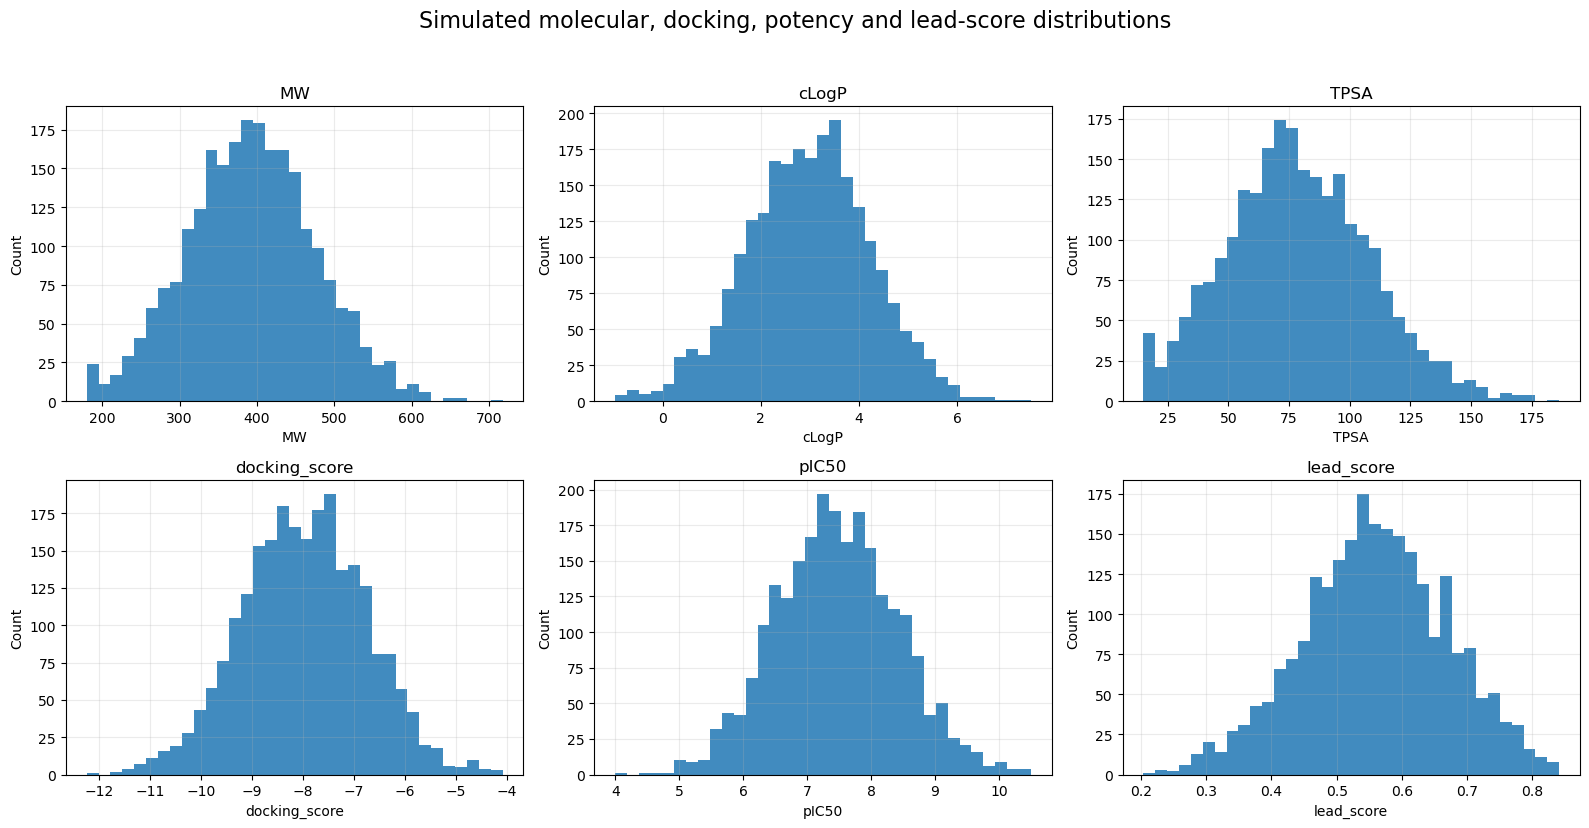

Saved: figures_ai4dd/02_target_potency_boxplot.png


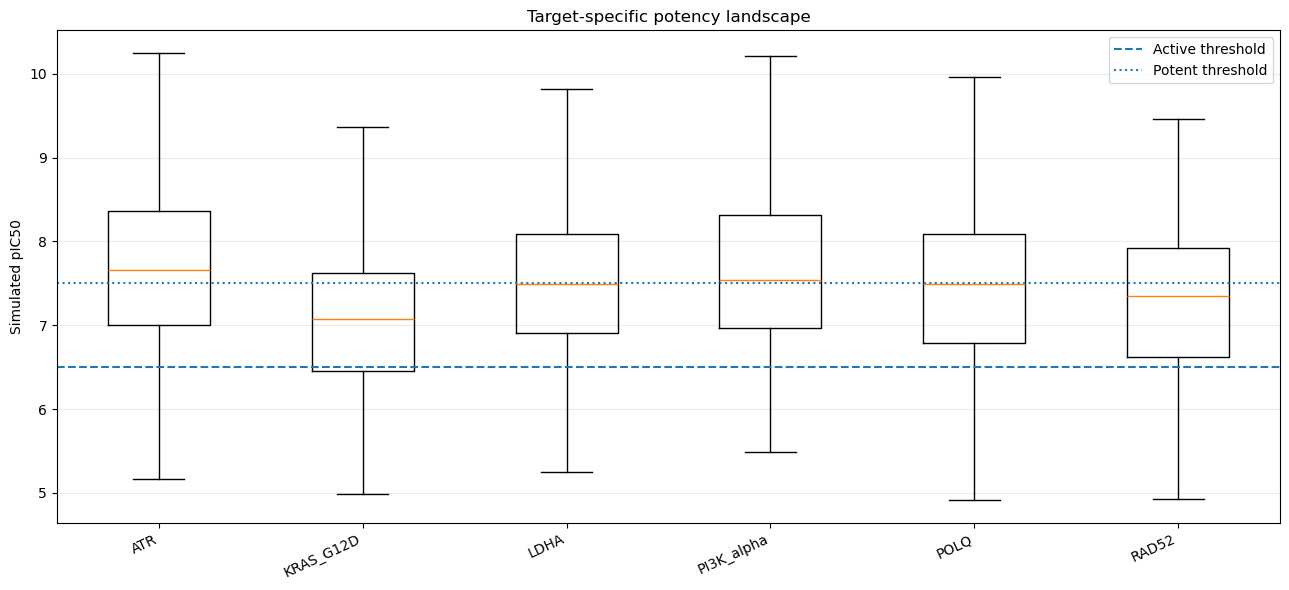

Saved: figures_ai4dd/03_docking_vs_potency.png


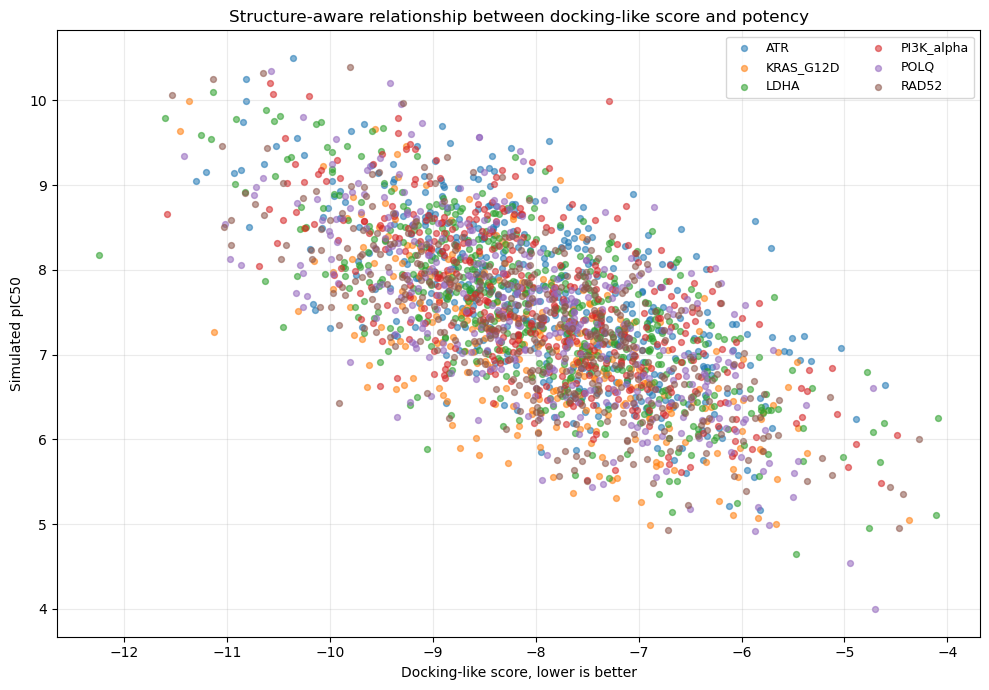

Saved: figures_ai4dd/04_potency_adme_space.png


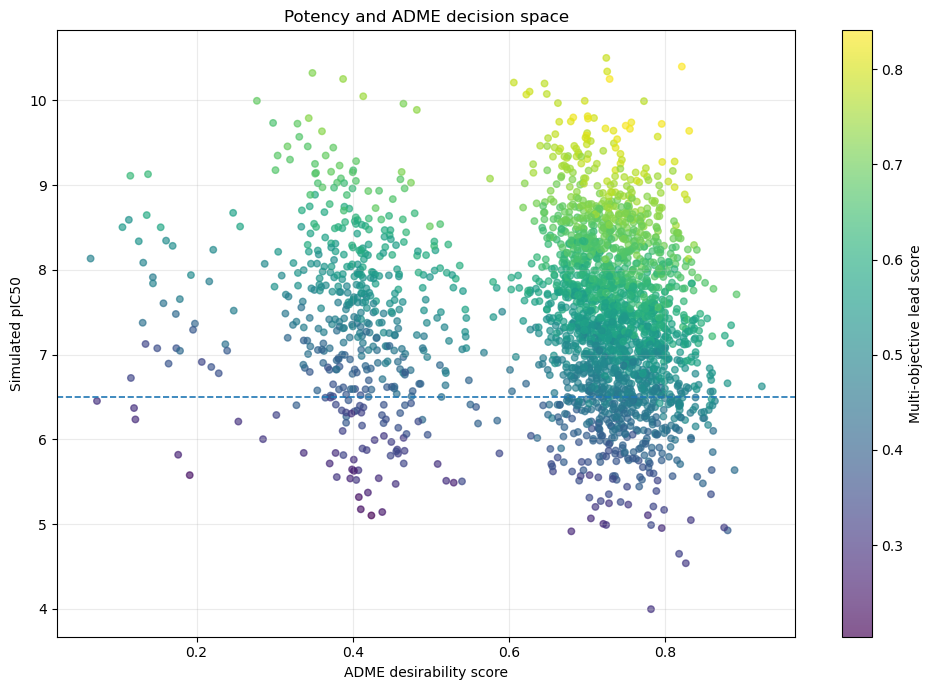

In [65]:
def distribution_panel(df, cols):
    fig, axes = plt.subplots(2, 3, figsize=(16, 8))
    axes = axes.ravel()
    for ax, col in zip(axes, cols):
        ax.hist(df[col], bins=35, alpha=0.85)
        ax.set_title(col)
        ax.set_xlabel(col)
        ax.set_ylabel("Count")
        ax.grid(alpha=0.25)
    fig.suptitle("Simulated molecular, docking, potency and lead-score distributions", fontsize=16, y=1.03)
    savefig("01_distribution_panel.png")
    plt.show()

distribution_panel(df, ["MW", "cLogP", "TPSA", "docking_score", "pIC50", "lead_score"])

plt.figure(figsize=(13, 6))
targets_order = sorted(df["target"].unique())
boxdata = [df.loc[df["target"] == t, "pIC50"].values for t in targets_order]
plt.boxplot(boxdata, labels=targets_order, showfliers=False)
plt.axhline(6.5, linestyle="--", linewidth=1.5, label="Active threshold")
plt.axhline(7.5, linestyle=":", linewidth=1.5, label="Potent threshold")
plt.ylabel("Simulated pIC50")
plt.title("Target-specific potency landscape")
plt.xticks(rotation=25, ha="right")
plt.grid(axis="y", alpha=0.25)
plt.legend()
savefig("02_target_potency_boxplot.png")
plt.show()

plt.figure(figsize=(10, 7))
for t in targets_order:
    s = df[df["target"] == t]
    plt.scatter(s["docking_score"], s["pIC50"], s=18, alpha=0.55, label=t)
plt.xlabel("Docking-like score, lower is better")
plt.ylabel("Simulated pIC50")
plt.title("Structure-aware relationship between docking-like score and potency")
plt.grid(alpha=0.25)
plt.legend(ncol=2, fontsize=9)
savefig("03_docking_vs_potency.png")
plt.show()

plt.figure(figsize=(10, 7))
sc = plt.scatter(df["adme_score"], df["pIC50"], s=22, alpha=0.65, c=df["lead_score"])
plt.colorbar(sc, label="Multi-objective lead score")
plt.axhline(6.5, linestyle="--", linewidth=1.2)
plt.xlabel("ADME desirability score")
plt.ylabel("Simulated pIC50")
plt.title("Potency and ADME decision space")
plt.grid(alpha=0.25)
savefig("04_potency_adme_space.png")
plt.show()

Saved: figures_ai4dd/05_pca_landscape.png


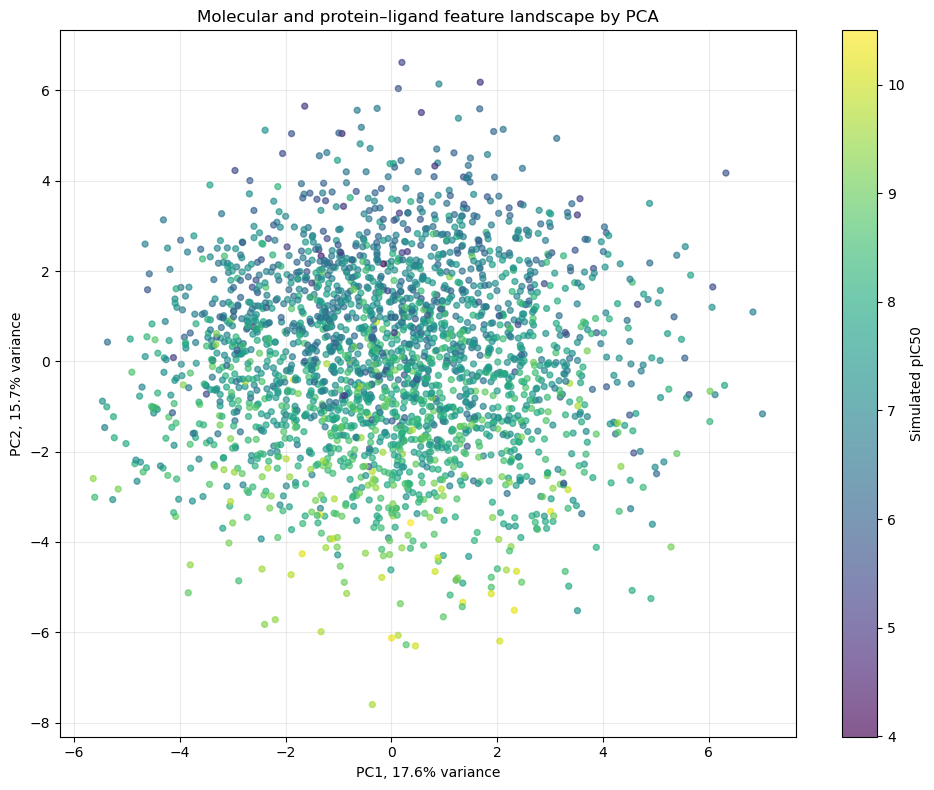

In [67]:
pca_features = [
    "MW", "cLogP", "HBD", "HBA", "TPSA", "rotatable_bonds", "aromatic_rings",
    "fraction_sp3", "hydrophobic_contacts", "hbonds", "electrostatic_contacts",
    "pi_stacking", "salt_bridges", "shape_complementarity", "buried_surface_area",
    "docking_score", "graph_latent_1", "graph_latent_2", "graph_latent_3",
    "graph_latent_4", "graph_latent_5", "logS", "permeability", "clearance_risk",
    "hERG_risk", "synthetic_accessibility"
]
X_scaled = StandardScaler().fit_transform(df[pca_features])
pca = PCA(n_components=2, random_state=RANDOM_STATE)
pc = pca.fit_transform(X_scaled)
df["PC1"] = pc[:, 0]
df["PC2"] = pc[:, 1]

plt.figure(figsize=(10, 8))
sc = plt.scatter(df["PC1"], df["PC2"], c=df["pIC50"], s=18, alpha=0.65)
plt.colorbar(sc, label="Simulated pIC50")
plt.xlabel(f"PC1, {pca.explained_variance_ratio_[0]*100:.1f}% variance")
plt.ylabel(f"PC2, {pca.explained_variance_ratio_[1]*100:.1f}% variance")
plt.title("Molecular and protein–ligand feature landscape by PCA")
plt.grid(alpha=0.25)
savefig("05_pca_landscape.png")
plt.show()

# 4. Modelling setup

The features include both molecular descriptors and target/protein–ligand context. The categorical target information is one-hot encoded inside the pipeline.

In [70]:
categorical_features = ["target", "target_family"]
numeric_features = [
    "MW", "cLogP", "HBD", "HBA", "TPSA", "rotatable_bonds", "aromatic_rings",
    "fraction_sp3", "hydrophobic_contacts", "hbonds", "electrostatic_contacts",
    "pi_stacking", "salt_bridges", "shape_complementarity", "buried_surface_area",
    "docking_score", "graph_latent_1", "graph_latent_2", "graph_latent_3",
    "graph_latent_4", "graph_latent_5", "logS", "permeability", "clearance_risk",
    "hERG_risk", "synthetic_accessibility", "lipinski_violations", "veber_pass",
    "adme_score"
]

X = df[categorical_features + numeric_features]
y_cls = df["active"]
y_reg = df["pIC50"]

X_train, X_test, y_train_cls, y_test_cls, y_train_reg, y_test_reg = train_test_split(
    X, y_cls, y_reg, test_size=0.25, random_state=RANDOM_STATE, stratify=y_cls
)

preprocessor = ColumnTransformer([
    ("num", StandardScaler(), numeric_features),
    ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
])

print("Train:", X_train.shape)
print("Test:", X_test.shape)

Train: (1800, 31)
Test: (600, 31)


# 5. Classification, predicting active compounds

,model,ROC_AUC,PR_AUC,accuracy,F1,precision,recall
0,Logistic regression,0.868428,0.972952,0.783333,0.858079,0.953883,0.779762
1,Random forest,0.856027,0.970188,0.855000,0.916746,0.885397,0.950397
2,Gradient boosting,0.833623,0.963398,0.858333,0.918348,0.890130,0.948413
3,MLP neural net,0.773851,0.947405,0.823333,0.896484,0.882692,0.910714


Saved: figures_ai4dd/06_classification_comparison.png


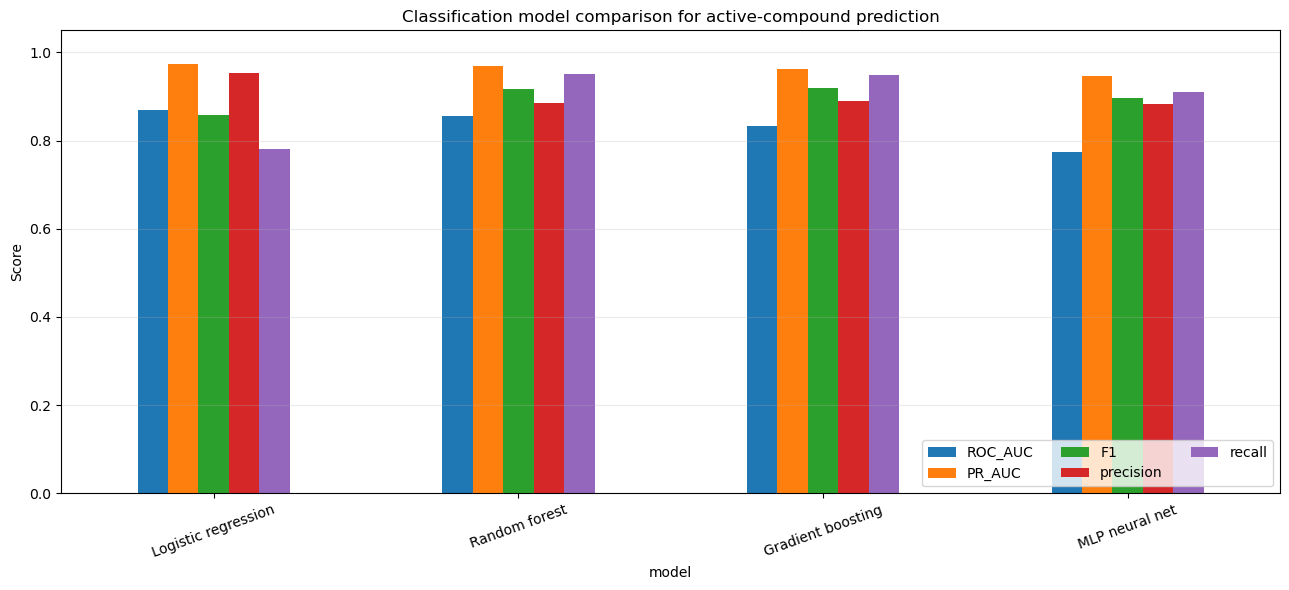

Saved: figures_ai4dd/07_best_classifier_roc.png


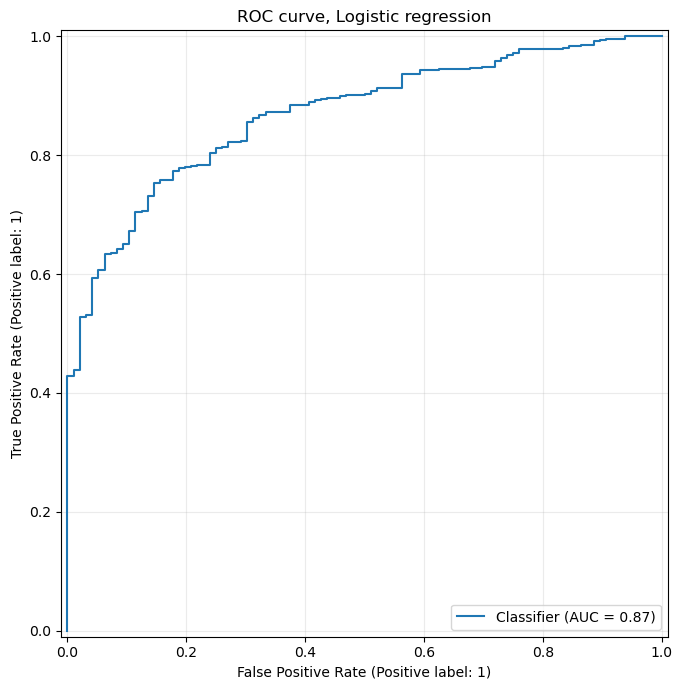

Saved: figures_ai4dd/08_best_classifier_pr.png


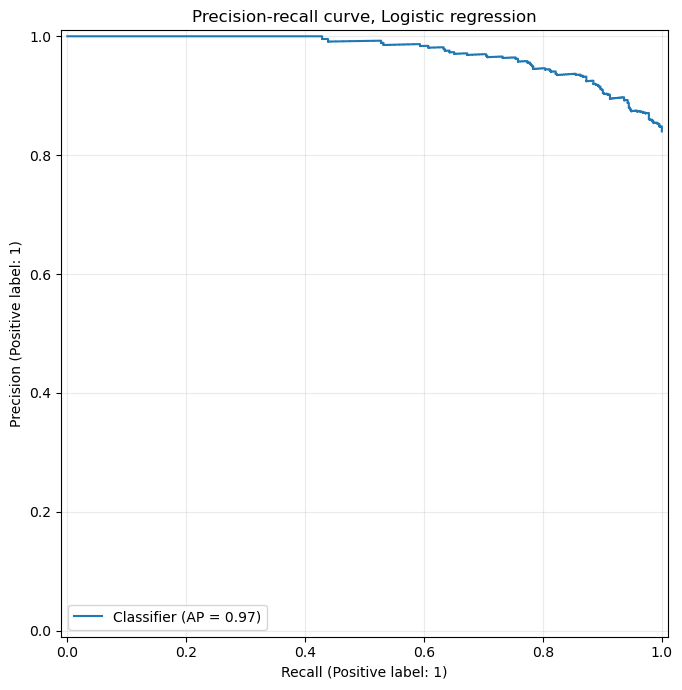

Saved: figures_ai4dd/09_confusion_matrix.png


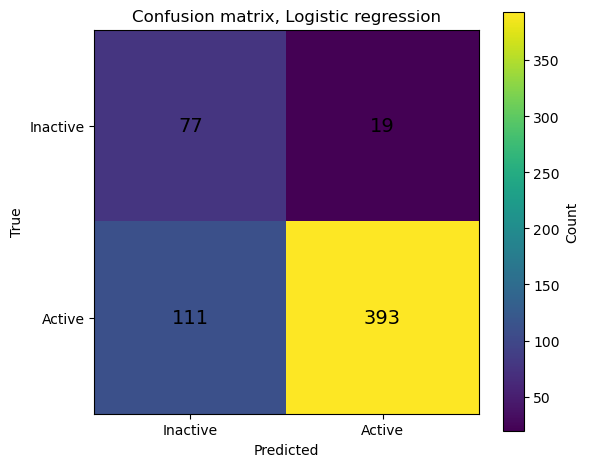

In [73]:
classifiers = {
    "Logistic regression": LogisticRegression(max_iter=2000, class_weight="balanced", random_state=RANDOM_STATE),
    "Random forest": RandomForestClassifier(n_estimators=350, min_samples_leaf=3, class_weight="balanced", random_state=RANDOM_STATE, n_jobs=-1),
    "Gradient boosting": GradientBoostingClassifier(random_state=RANDOM_STATE),
    "MLP neural net": MLPClassifier(hidden_layer_sizes=(96, 48), activation="relu", alpha=1e-4, max_iter=600, random_state=RANDOM_STATE)
}

cls_results, trained_cls = [], {}

for name, model in classifiers.items():
    pipe = Pipeline([("prep", preprocessor), ("model", model)])
    pipe.fit(X_train, y_train_cls)
    trained_cls[name] = pipe
    proba = pipe.predict_proba(X_test)[:, 1]
    pred = (proba >= 0.5).astype(int)
    cls_results.append({
        "model": name,
        "ROC_AUC": roc_auc_score(y_test_cls, proba),
        "PR_AUC": average_precision_score(y_test_cls, proba),
        "accuracy": accuracy_score(y_test_cls, pred),
        "F1": f1_score(y_test_cls, pred),
        "precision": precision_score(y_test_cls, pred),
        "recall": recall_score(y_test_cls, pred)
    })

cls_results_df = pd.DataFrame(cls_results).sort_values("ROC_AUC", ascending=False)
display(cls_results_df)

best_cls_name = cls_results_df.iloc[0]["model"]
best_cls = trained_cls[best_cls_name]
best_proba = best_cls.predict_proba(X_test)[:, 1]

ax = cls_results_df.set_index("model")[["ROC_AUC", "PR_AUC", "F1", "precision", "recall"]].plot(kind="bar", figsize=(13, 6), rot=20)
ax.set_ylim(0, 1.05)
ax.set_ylabel("Score")
ax.set_title("Classification model comparison for active-compound prediction")
ax.grid(axis="y", alpha=0.25)
plt.legend(loc="lower right", ncol=3)
savefig("06_classification_comparison.png")
plt.show()

fig, ax = plt.subplots(figsize=(8, 7))
RocCurveDisplay.from_predictions(y_test_cls, best_proba, ax=ax)
ax.set_title(f"ROC curve, {best_cls_name}")
ax.grid(alpha=0.25)
savefig("07_best_classifier_roc.png")
plt.show()

fig, ax = plt.subplots(figsize=(8, 7))
PrecisionRecallDisplay.from_predictions(y_test_cls, best_proba, ax=ax)
ax.set_title(f"Precision-recall curve, {best_cls_name}")
ax.grid(alpha=0.25)
savefig("08_best_classifier_pr.png")
plt.show()

cm = confusion_matrix(y_test_cls, (best_proba >= 0.5).astype(int))
plt.figure(figsize=(6, 5))
plt.imshow(cm)
plt.title(f"Confusion matrix, {best_cls_name}")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.xticks([0, 1], ["Inactive", "Active"])
plt.yticks([0, 1], ["Inactive", "Active"])
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, str(cm[i, j]), ha="center", va="center", fontsize=14)
plt.colorbar(label="Count")
savefig("09_confusion_matrix.png")
plt.show()

# 6. Regression, predicting continuous pIC50

,model,RMSE,MAE,R2
0,Ridge regression,0.607418,0.486299,0.597508
2,Gradient boosting regressor,0.631680,0.506693,0.564712
1,Random forest regressor,0.637826,0.509531,0.556201
3,MLP regressor,0.883736,0.714939,0.148024


Saved: figures_ai4dd/10_regression_comparison.png


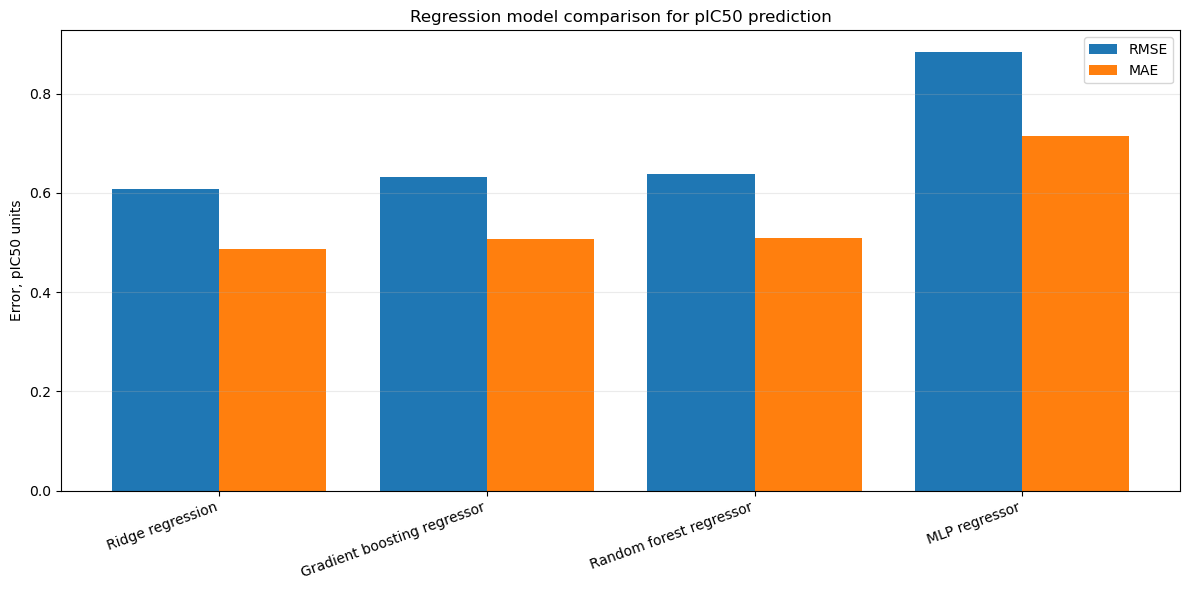

Saved: figures_ai4dd/11_predicted_vs_observed.png


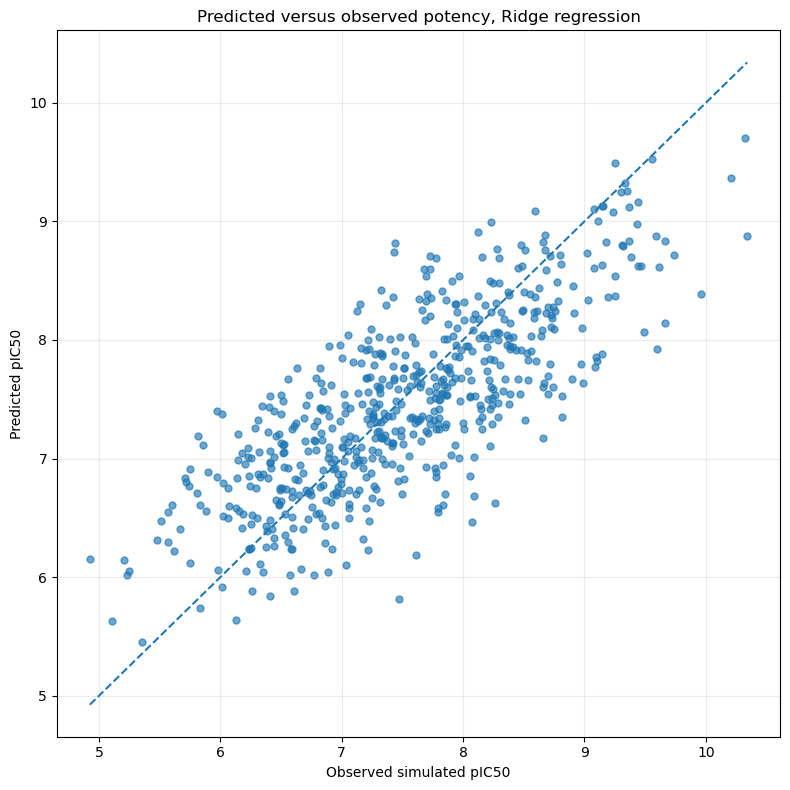

In [76]:
regressors = {
    "Ridge regression": Ridge(alpha=1.0, random_state=RANDOM_STATE),
    "Random forest regressor": RandomForestRegressor(n_estimators=350, min_samples_leaf=3, random_state=RANDOM_STATE, n_jobs=-1),
    "Gradient boosting regressor": GradientBoostingRegressor(random_state=RANDOM_STATE),
    "MLP regressor": MLPRegressor(hidden_layer_sizes=(128, 64), activation="relu", alpha=1e-4, max_iter=700, random_state=RANDOM_STATE)
}

reg_results, trained_reg = [], {}

for name, model in regressors.items():
    pipe = Pipeline([("prep", preprocessor), ("model", model)])
    pipe.fit(X_train, y_train_reg)
    trained_reg[name] = pipe
    pred_reg = pipe.predict(X_test)
    reg_results.append({
        "model": name,
        "RMSE": np.sqrt(mean_squared_error(y_test_reg, pred_reg)),
        "MAE": mean_absolute_error(y_test_reg, pred_reg),
        "R2": r2_score(y_test_reg, pred_reg)
    })

reg_results_df = pd.DataFrame(reg_results).sort_values("RMSE")
display(reg_results_df)

best_reg_name = reg_results_df.iloc[0]["model"]
best_reg = trained_reg[best_reg_name]
pred_reg_best = best_reg.predict(X_test)

fig, ax = plt.subplots(figsize=(12, 6))
xpos = np.arange(len(reg_results_df))
ax.bar(xpos - 0.2, reg_results_df["RMSE"], width=0.4, label="RMSE")
ax.bar(xpos + 0.2, reg_results_df["MAE"], width=0.4, label="MAE")
ax.set_xticks(xpos)
ax.set_xticklabels(reg_results_df["model"], rotation=20, ha="right")
ax.set_ylabel("Error, pIC50 units")
ax.set_title("Regression model comparison for pIC50 prediction")
ax.grid(axis="y", alpha=0.25)
ax.legend()
savefig("10_regression_comparison.png")
plt.show()

plt.figure(figsize=(8, 8))
plt.scatter(y_test_reg, pred_reg_best, s=25, alpha=0.65)
lims = [min(y_test_reg.min(), pred_reg_best.min()), max(y_test_reg.max(), pred_reg_best.max())]
plt.plot(lims, lims, linestyle="--", linewidth=1.5)
plt.xlabel("Observed simulated pIC50")
plt.ylabel("Predicted pIC50")
plt.title(f"Predicted versus observed potency, {best_reg_name}")
plt.grid(alpha=0.25)
savefig("11_predicted_vs_observed.png")
plt.show()

# 7. Explainable AI

Global feature importance identifies the molecular and protein–ligand factors that most influence active-compound prediction.

,feature,importance_mean,importance_sd
17,docking_score,0.120153,0.013574
15,shape_complementarity,0.026595,0.006049
10,hydrophobic_contacts,0.023096,0.006910
11,hbonds,0.020694,0.006635
2,MW,0.017351,0.003685
13,pi_stacking,0.009009,0.005475
1,target_family,0.008389,0.005124
3,cLogP,0.007087,0.002236
22,graph_latent_5,0.005110,0.002965
0,target,0.004606,0.003303


Saved: figures_ai4dd/12_permutation_importance.png


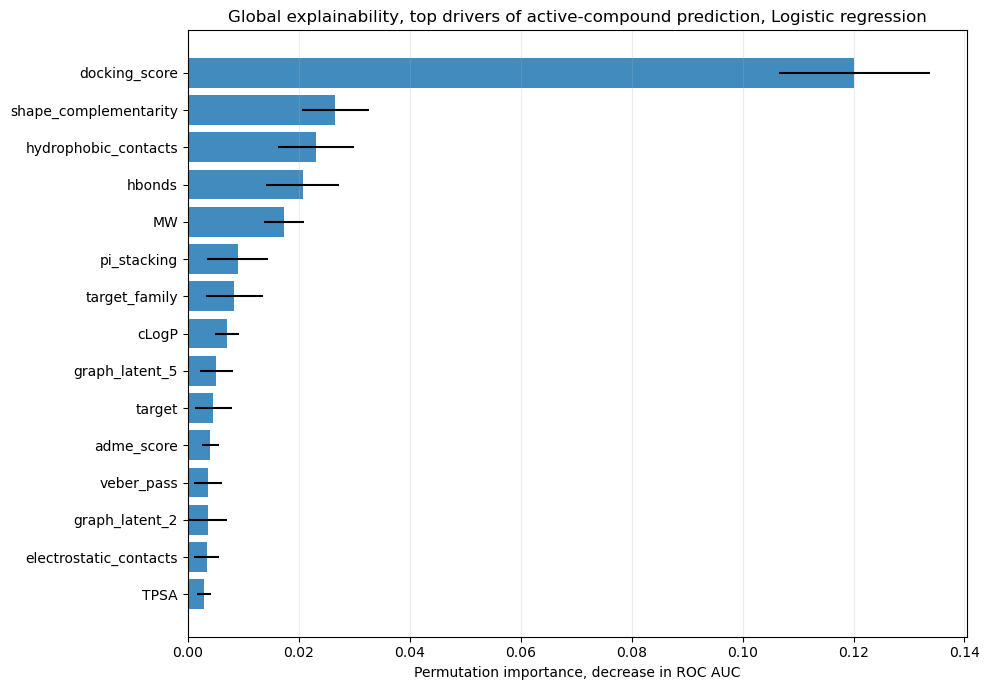

Saved: figures_ai4dd/13_partial_dependence.png


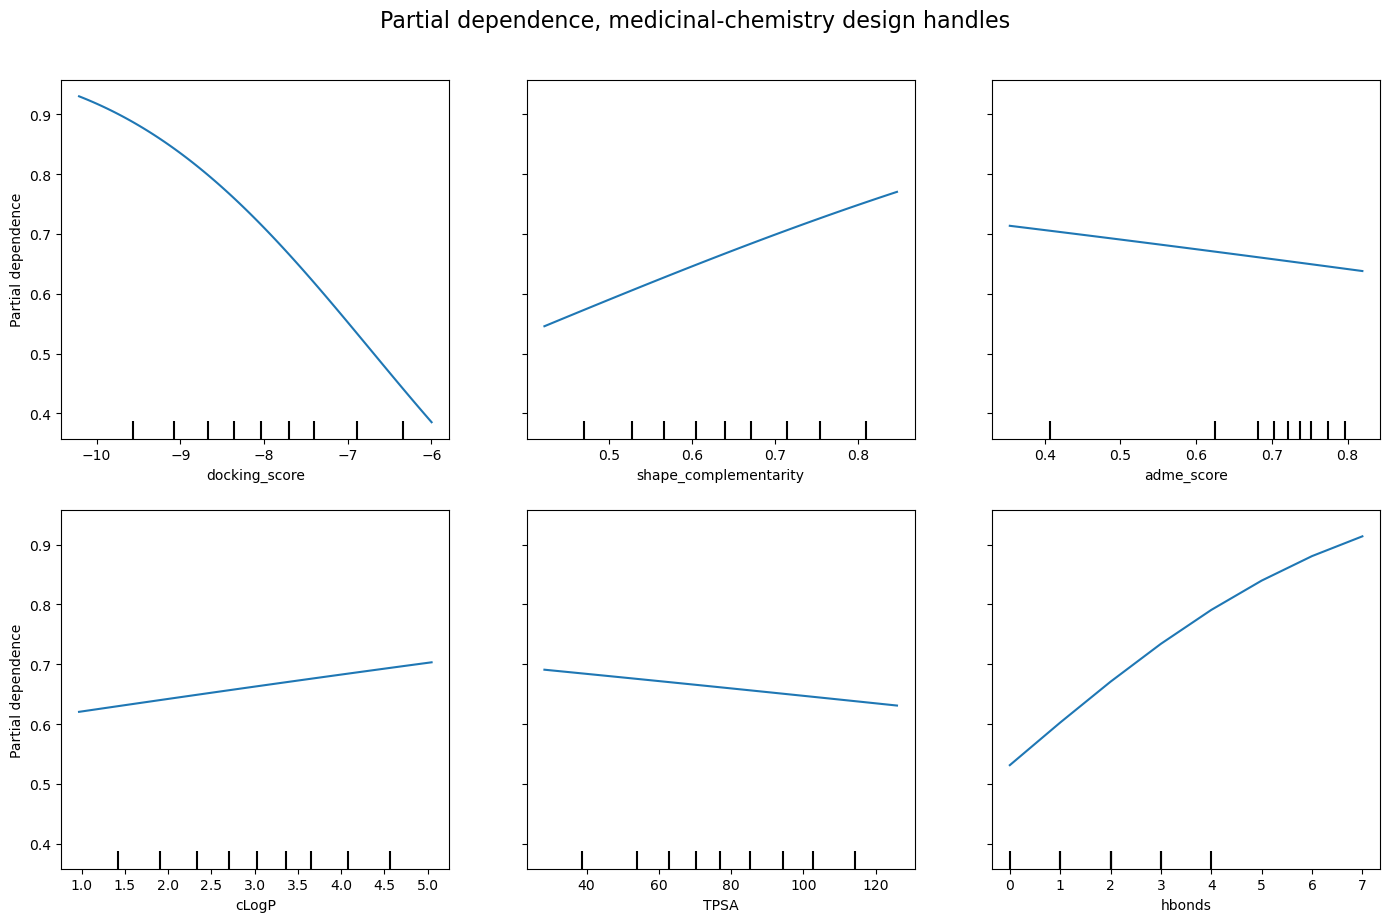

In [78]:
X_test_small = X_test.sample(min(600, len(X_test)), random_state=RANDOM_STATE)
y_test_small = y_test_cls.loc[X_test_small.index]

perm = permutation_importance(
    best_cls, X_test_small, y_test_small,
    scoring="roc_auc", n_repeats=8, random_state=RANDOM_STATE, n_jobs=-1
)

importance_df = pd.DataFrame({
    "feature": categorical_features + numeric_features,
    "importance_mean": perm.importances_mean,
    "importance_sd": perm.importances_std
}).sort_values("importance_mean", ascending=False)

display(importance_df.head(15))

top_imp = importance_df.head(15).iloc[::-1]
plt.figure(figsize=(10, 7))
plt.barh(top_imp["feature"], top_imp["importance_mean"], xerr=top_imp["importance_sd"], alpha=0.85)
plt.xlabel("Permutation importance, decrease in ROC AUC")
plt.title(f"Global explainability, top drivers of active-compound prediction, {best_cls_name}")
plt.grid(axis="x", alpha=0.25)
savefig("12_permutation_importance.png")
plt.show()

try:
    features_to_plot = ["docking_score", "shape_complementarity", "adme_score", "cLogP", "TPSA", "hbonds"]
    fig, ax = plt.subplots(figsize=(14, 9))
    PartialDependenceDisplay.from_estimator(best_cls, X_test_small, features_to_plot, ax=ax)
    fig.suptitle("Partial dependence, medicinal-chemistry design handles", fontsize=16, y=1.02)
    savefig("13_partial_dependence.png")
    plt.show()
except Exception as e:
    print("Partial dependence skipped:", e)

# 8. Local explanation agent

This agent explains why a specific molecule was prioritised, using model importance plus molecule-specific feature values.

In [81]:
class LocalExplanationAgent:
    def __init__(self, model, importance_df, reference_df, numeric_features):
        self.model = model
        self.importance_df = importance_df
        self.reference_df = reference_df
        self.numeric_features = numeric_features
        self.medians = reference_df[numeric_features].median()

    def explain_compound(self, row, top_n=8):
        row_df = pd.DataFrame([row[categorical_features + numeric_features]])
        probability = float(self.model.predict_proba(row_df)[:, 1][0])
        top_features = self.importance_df.head(top_n)["feature"].tolist()
        statements = []
        for feat in top_features:
            if feat in self.numeric_features:
                val = float(row[feat])
                med = float(self.medians[feat])
                direction = "above" if val > med else "below"
                statements.append(f"{feat}: {val:.3g}, {direction} median {med:.3g}")
            else:
                statements.append(f"{feat}: {row[feat]}")

        if row["pIC50"] >= 7.5 and row["adme_score"] >= 0.65 and row["hERG_risk"] < 0.45:
            rec = "High-confidence lead-like candidate for confirmatory testing."
        elif row["pIC50"] >= 6.5 and row["adme_score"] < 0.55:
            rec = "Potent but ADME-constrained candidate, optimise liabilities."
        elif row["pIC50"] < 6.5 and row["adme_score"] >= 0.70:
            rec = "ADME-attractive but potency-limited candidate."
        else:
            rec = "Lower-priority candidate unless scaffold novelty is valuable."

        return {
            "compound_id": row["compound_id"],
            "target": row["target"],
            "predicted_active_probability": round(probability, 3),
            "simulated_pIC50": round(float(row["pIC50"]), 3),
            "lead_score": round(float(row["lead_score"]), 3),
            "top_explanatory_features": statements,
            "agent_recommendation": rec
        }

test_df = df.loc[X_test.index].copy()
test_df["predicted_active_probability"] = best_proba
candidate = test_df.sort_values(["lead_score", "predicted_active_probability"], ascending=False).iloc[0]

local_agent = LocalExplanationAgent(best_cls, importance_df, df, numeric_features)
local_agent.explain_compound(candidate)

{'compound_id': 'AI4DD_02266',
 'target': 'KRAS_G12D',
 'predicted_active_probability': 0.998,
 'simulated_pIC50': 9.663,
 'lead_score': 0.831,
 'top_explanatory_features': ['docking_score: -9.56, below median -7.98',
  'shape_complementarity: 0.878, above median 0.635',
  'hydrophobic_contacts: 10, above median 6',
  'hbonds: 6, above median 2',
  'MW: 239, below median 392',
  'pi_stacking: 2, below median 2',
  'target_family: small_GTPase',
  'cLogP: 2.2, below median 2.99'],
 'agent_recommendation': 'High-confidence lead-like candidate for confirmatory testing.'}

# 9. Uncertainty and applicability-domain analysis

This section asks whether predictions are reliable enough to support action.

Saved: figures_ai4dd/14_uncertainty_domain.png


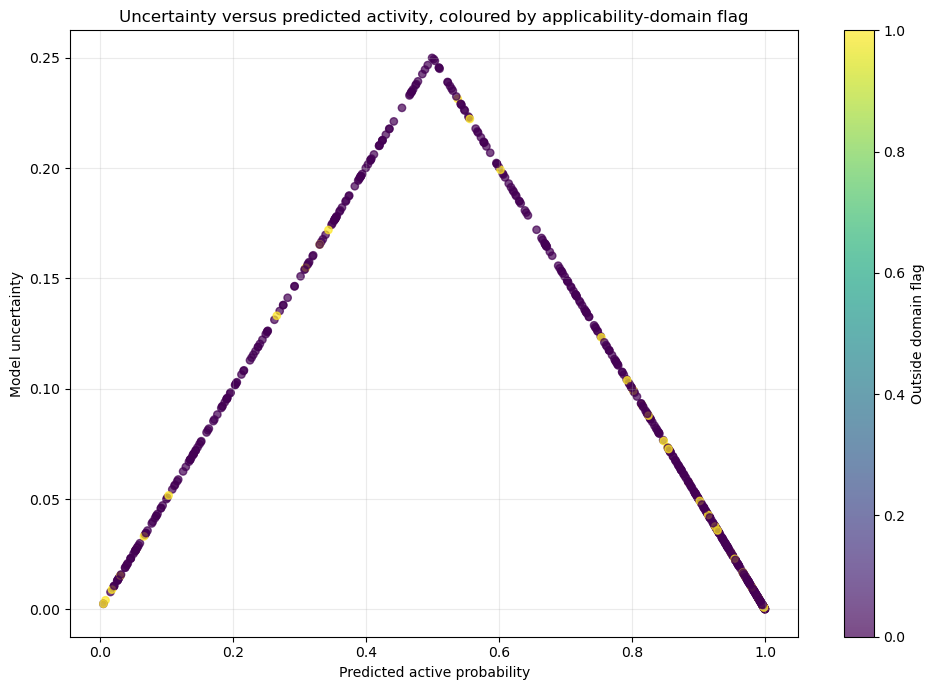

,compound_id,target,pIC50,predicted_active_probability,model_uncertainty,applicability_score,outside_domain,lead_score
2266,AI4DD_02266,KRAS_G12D,9.662978,0.997985,0.001009,0.006136,0,0.830642
97,AI4DD_00097,LDHA,9.739236,0.996541,0.001732,0.069680,0,0.825813
1375,AI4DD_01375,LDHA,9.667403,0.958975,0.020545,0.104482,0,0.820481
1115,AI4DD_01115,LDHA,9.585502,0.996581,0.001712,0.086557,0,0.813871
476,AI4DD_00476,RAD52,9.439911,0.999140,0.000431,0.053247,0,0.811134
279,AI4DD_00279,PI3K_alpha,9.253316,0.992973,0.003519,0.032378,0,0.806828
1159,AI4DD_01159,KRAS_G12D,9.367907,0.997576,0.001214,-0.002350,1,0.798451
558,AI4DD_00558,POLQ,10.340028,0.997407,0.001299,0.072141,0,0.797219
1854,AI4DD_01854,PI3K_alpha,9.557441,0.999833,0.000083,0.022654,0,0.796076
734,AI4DD_00734,LDHA,9.306669,0.997711,0.001146,0.076644,0,0.793037


In [83]:
def estimate_uncertainty(model_pipeline, X_data):
    model = model_pipeline.named_steps["model"]
    X_trans = model_pipeline.named_steps["prep"].transform(X_data)
    if hasattr(model, "estimators_") and "Forest" in model.__class__.__name__:
        tree_probs = np.vstack([est.predict_proba(X_trans)[:, 1] for est in model.estimators_])
        return tree_probs.mean(axis=0), tree_probs.std(axis=0)
    prob = model_pipeline.predict_proba(X_data)[:, 1]
    uncertainty = 1 - np.abs(prob - 0.5) * 2
    return prob, uncertainty / (uncertainty.max() + 1e-9) * 0.25

mean_prob, uncertainty = estimate_uncertainty(best_cls, X_test)
test_df["model_uncertainty"] = uncertainty

X_train_trans = best_cls.named_steps["prep"].transform(X_train)
X_test_trans = best_cls.named_steps["prep"].transform(X_test)

iso = IsolationForest(contamination=0.07, random_state=RANDOM_STATE)
iso.fit(X_train_trans)
test_df["applicability_score"] = iso.decision_function(X_test_trans)
test_df["outside_domain"] = (iso.predict(X_test_trans) == -1).astype(int)

plt.figure(figsize=(10, 7))
sc = plt.scatter(test_df["predicted_active_probability"], test_df["model_uncertainty"], c=test_df["outside_domain"], s=28, alpha=0.70)
plt.xlabel("Predicted active probability")
plt.ylabel("Model uncertainty")
plt.title("Uncertainty versus predicted activity, coloured by applicability-domain flag")
plt.grid(alpha=0.25)
plt.colorbar(sc, label="Outside domain flag")
savefig("14_uncertainty_domain.png")
plt.show()

display(test_df[["compound_id", "target", "pIC50", "predicted_active_probability", "model_uncertainty", "applicability_score", "outside_domain", "lead_score"]].sort_values("lead_score", ascending=False).head(15))

# 10. Calibration

Probability calibration checks whether model probabilities behave like meaningful probabilities.

Saved: figures_ai4dd/15_calibration_curve.png


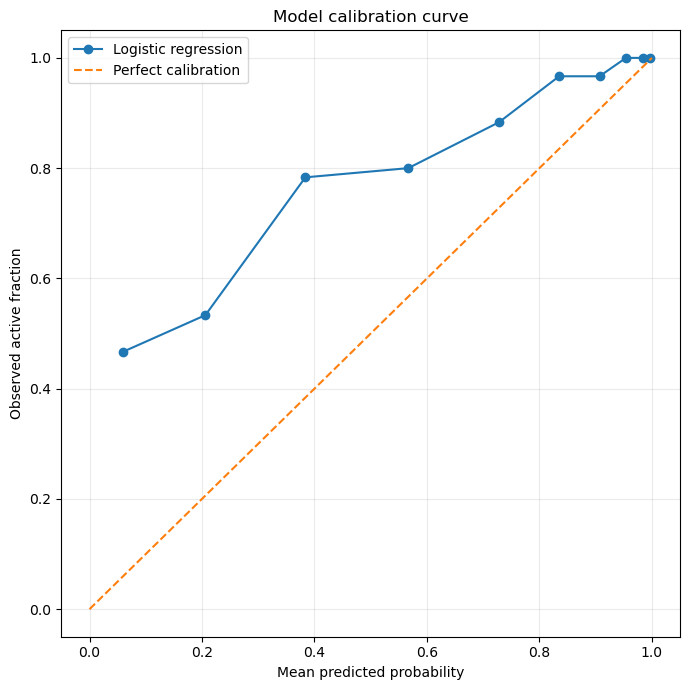

In [88]:
prob_true, prob_pred = calibration_curve(y_test_cls, best_proba, n_bins=10, strategy="quantile")

plt.figure(figsize=(7, 7))
plt.plot(prob_pred, prob_true, marker="o", label=best_cls_name)
plt.plot([0, 1], [0, 1], linestyle="--", label="Perfect calibration")
plt.xlabel("Mean predicted probability")
plt.ylabel("Observed active fraction")
plt.title("Model calibration curve")
plt.grid(alpha=0.25)
plt.legend()
savefig("15_calibration_curve.png")
plt.show()

# 11. Multi-objective lead prioritisation

The agent ranks molecules using predicted potency, ADME score, model confidence, applicability-domain score, and synthetic tractability.

,compound_id,target,predicted_pIC50,pIC50,predicted_active_probability,adme_score,hERG_risk,synthetic_accessibility,confidence_score,outside_domain,agentic_priority_score
1810,AI4DD_01810,ATR,8.641502,8.804366,0.997117,0.763944,0.719957,4.505179,0.994225,0,0.841298
2368,AI4DD_02368,ATR,9.489898,9.253616,0.999662,0.692769,0.744973,6.284522,0.999322,0,0.841226
476,AI4DD_00476,RAD52,9.165002,9.439911,0.999140,0.736778,0.443405,6.158046,0.998278,0,0.835374
1303,AI4DD_01303,ATR,8.695267,7.775661,0.994394,0.862102,0.084841,4.990817,0.988770,0,0.834949
1854,AI4DD_01854,PI3K_alpha,9.521882,9.557441,0.999833,0.698160,0.900833,6.626141,0.999666,0,0.827771
97,AI4DD_00097,LDHA,8.718400,9.739236,0.996541,0.756906,0.696803,5.398411,0.993072,0,0.826533
36,AI4DD_00036,LDHA,9.321777,9.334868,0.999844,0.656491,0.920224,7.100252,0.999687,0,0.823939
1017,AI4DD_01017,PI3K_alpha,8.979942,9.430356,0.998316,0.665860,0.803619,5.005567,0.996627,0,0.823166
668,AI4DD_00668,ATR,8.422175,7.327511,0.990715,0.823042,0.431601,4.433075,0.981400,0,0.821970
1115,AI4DD_01115,LDHA,8.874649,9.585502,0.996581,0.699345,0.656754,6.497902,0.993151,0,0.821908


Saved: figures_ai4dd/16_multiobjective_landscape.png


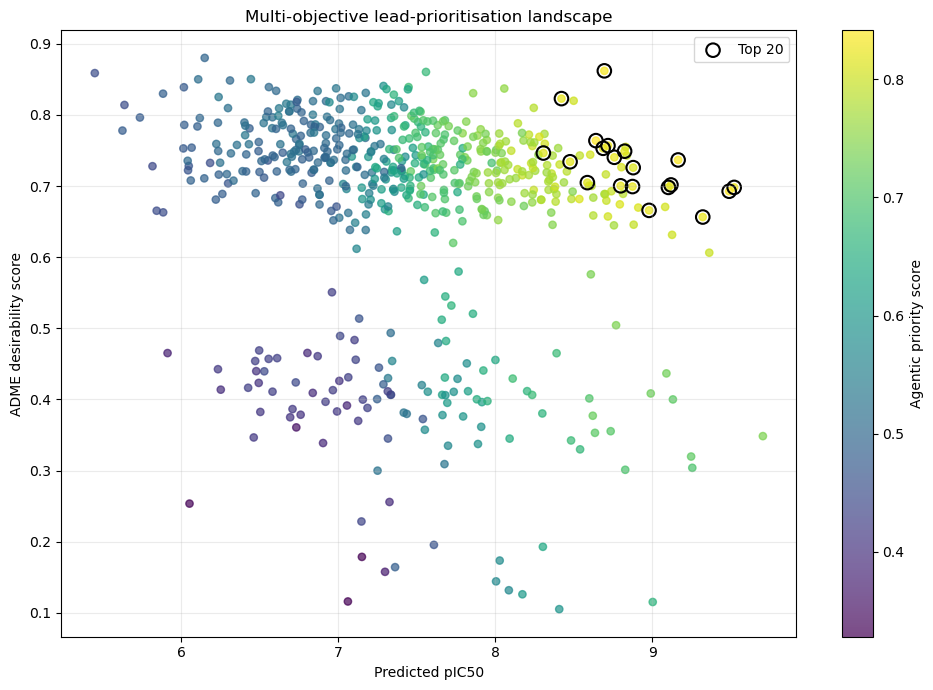

In [91]:
triage_df = test_df.copy()
triage_df["predicted_pIC50"] = best_reg.predict(X_test)
triage_df["confidence_score"] = 1 - np.clip(triage_df["model_uncertainty"] / (triage_df["model_uncertainty"].max() + 1e-9), 0, 1)
triage_df["domain_score"] = np.clip(
    (triage_df["applicability_score"] - triage_df["applicability_score"].min()) /
    (triage_df["applicability_score"].max() - triage_df["applicability_score"].min() + 1e-9), 0, 1
)

triage_df["agentic_priority_score"] = (
    0.30*np.clip((triage_df["predicted_pIC50"]-5)/4.5, 0, 1)
    + 0.20*triage_df["adme_score"]
    + 0.15*triage_df["predicted_active_probability"]
    + 0.15*triage_df["confidence_score"]
    + 0.10*triage_df["domain_score"]
    + 0.10*(1 - np.clip((triage_df["synthetic_accessibility"]-1)/8.5, 0, 1))
)

top_candidates = triage_df.sort_values("agentic_priority_score", ascending=False).head(20)

display(top_candidates[[
    "compound_id", "target", "predicted_pIC50", "pIC50", "predicted_active_probability",
    "adme_score", "hERG_risk", "synthetic_accessibility", "confidence_score",
    "outside_domain", "agentic_priority_score"
]])

plt.figure(figsize=(10, 7))
sc = plt.scatter(triage_df["predicted_pIC50"], triage_df["adme_score"], c=triage_df["agentic_priority_score"], s=28, alpha=0.70)
plt.scatter(top_candidates["predicted_pIC50"], top_candidates["adme_score"], s=95, facecolors="none", edgecolors="black", linewidths=1.5, label="Top 20")
plt.xlabel("Predicted pIC50")
plt.ylabel("ADME desirability score")
plt.title("Multi-objective lead-prioritisation landscape")
plt.colorbar(sc, label="Agentic priority score")
plt.grid(alpha=0.25)
plt.legend()
savefig("16_multiobjective_landscape.png")
plt.show()

# 12. Medicinal chemistry triage agent

,compound_id,target,predicted_pIC50,adme_score,hERG_risk,synthetic_accessibility,confidence_score,outside_domain,agentic_priority_score,decision,rationale,next_action
0,AI4DD_01810,ATR,8.641502,0.763944,0.719957,4.505179,0.994225,0,0.841298,Advance,strong predicted potency; favourable simulated...,reduce lipophilicity and aromatic burden
1,AI4DD_02368,ATR,9.489898,0.692769,0.744973,6.284522,0.999322,0,0.841226,Advance,strong predicted potency; acceptable but optim...,reduce lipophilicity and aromatic burden
2,AI4DD_00476,RAD52,9.165002,0.736778,0.443405,6.158046,0.998278,0,0.835374,Advance,strong predicted potency; favourable simulated...,prioritise for confirmatory assay and orthogon...
3,AI4DD_01303,ATR,8.695267,0.862102,0.084841,4.990817,0.988770,0,0.834949,Advance,strong predicted potency; favourable simulated...,prioritise for confirmatory assay and orthogon...
4,AI4DD_01854,PI3K_alpha,9.521882,0.698160,0.900833,6.626141,0.999666,0,0.827771,Advance,strong predicted potency; acceptable but optim...,reduce lipophilicity and aromatic burden; simp...
5,AI4DD_00097,LDHA,8.718400,0.756906,0.696803,5.398411,0.993072,0,0.826533,Advance,strong predicted potency; favourable simulated...,reduce lipophilicity and aromatic burden
6,AI4DD_00036,LDHA,9.321777,0.656491,0.920224,7.100252,0.999687,0,0.823939,Advance,strong predicted potency; acceptable but optim...,reduce lipophilicity and aromatic burden; simp...
7,AI4DD_01017,PI3K_alpha,8.979942,0.665860,0.803619,5.005567,0.996627,0,0.823166,Advance,strong predicted potency; acceptable but optim...,reduce lipophilicity and aromatic burden
8,AI4DD_00668,ATR,8.422175,0.823042,0.431601,4.433075,0.981400,0,0.821970,Advance,strong predicted potency; favourable simulated...,prioritise for confirmatory assay and orthogon...
9,AI4DD_01115,LDHA,8.874649,0.699345,0.656754,6.497902,0.993151,0,0.821908,Advance,strong predicted potency; acceptable but optim...,reduce lipophilicity and aromatic burden


Saved: figures_ai4dd/17_agentic_triage_decisions.png


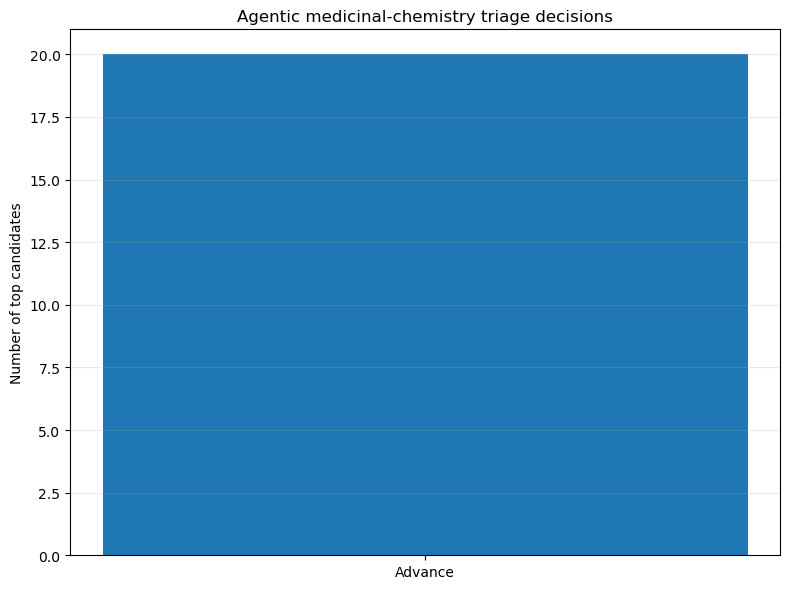

In [94]:
class MedicinalChemistryTriageAgent:
    def triage(self, row):
        reasons, actions = [], []

        if row["predicted_pIC50"] >= 7.5:
            reasons.append("strong predicted potency")
        elif row["predicted_pIC50"] >= 6.5:
            reasons.append("moderate predicted potency")
        else:
            reasons.append("potency requires improvement")

        if row["adme_score"] >= 0.70:
            reasons.append("favourable simulated ADME profile")
        elif row["adme_score"] >= 0.55:
            reasons.append("acceptable but optimisable ADME profile")
        else:
            reasons.append("ADME liabilities present")

        if row["hERG_risk"] > 0.55:
            reasons.append("elevated simulated hERG risk")
            actions.append("reduce lipophilicity and aromatic burden")

        if row["synthetic_accessibility"] > 6.5:
            reasons.append("synthetic complexity risk")
            actions.append("simplify scaffold")

        if row["outside_domain"] == 1:
            reasons.append("outside model applicability domain")
            actions.append("seek nearest-neighbour or orthogonal assay support")

        if row["confidence_score"] < 0.60:
            reasons.append("lower model confidence")
            actions.append("prioritise uncertainty-reducing experiments")

        if not actions:
            actions.append("prioritise for confirmatory assay and orthogonal validation")

        if row["agentic_priority_score"] >= 0.78 and row["outside_domain"] == 0:
            decision = "Advance"
        elif row["agentic_priority_score"] >= 0.65:
            decision = "Advance with caution"
        elif row["agentic_priority_score"] >= 0.55:
            decision = "Optimise"
        else:
            decision = "Deprioritise"

        return pd.Series({"decision": decision, "rationale": "; ".join(reasons), "next_action": "; ".join(actions)})

triage_agent = MedicinalChemistryTriageAgent()
annotations = top_candidates.apply(triage_agent.triage, axis=1)
top_candidates_annotated = pd.concat([top_candidates.reset_index(drop=True), annotations.reset_index(drop=True)], axis=1)

display(top_candidates_annotated[[
    "compound_id", "target", "predicted_pIC50", "adme_score", "hERG_risk",
    "synthetic_accessibility", "confidence_score", "outside_domain",
    "agentic_priority_score", "decision", "rationale", "next_action"
]].head(12))

decision_counts = top_candidates_annotated["decision"].value_counts()
plt.figure(figsize=(8, 6))
plt.bar(decision_counts.index, decision_counts.values)
plt.ylabel("Number of top candidates")
plt.title("Agentic medicinal-chemistry triage decisions")
plt.grid(axis="y", alpha=0.25)
savefig("17_agentic_triage_decisions.png")
plt.show()

# 13. Active-learning acquisition

This simulated active-learning module selects compounds likely to improve the model under limited assay budget.

Saved: figures_ai4dd/18_active_learning_acquisition.png


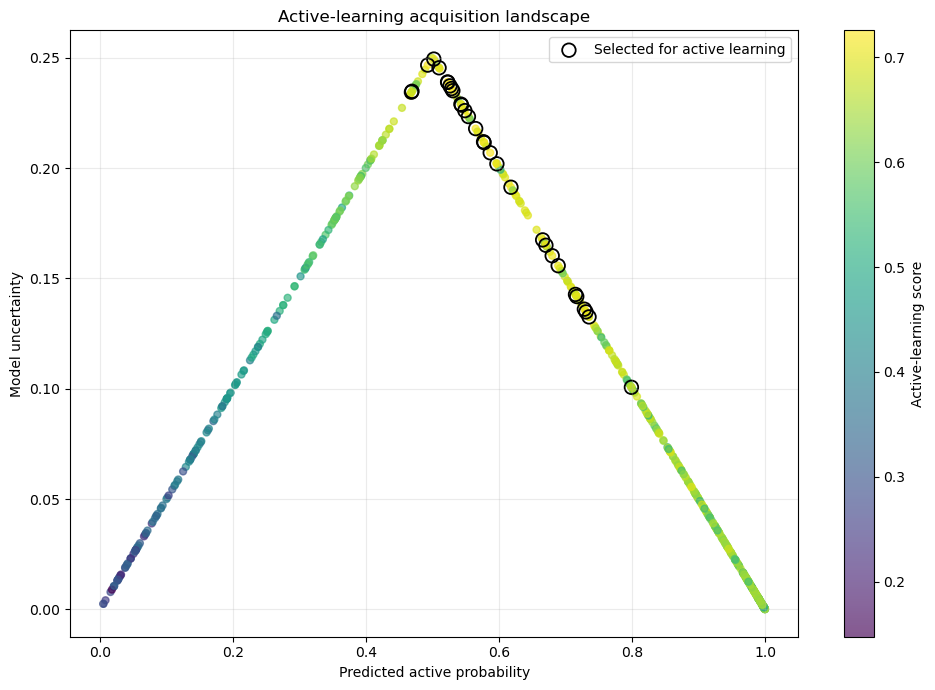

,compound_id,target,predicted_active_probability,model_uncertainty,adme_score,domain_score,cluster,active_learning_score
1362,AI4DD_01362,POLQ,0.526128,0.237306,0.767859,0.856313,4,0.725698
884,AI4DD_00884,LDHA,0.522566,0.239089,0.751618,0.768094,10,0.723282
902,AI4DD_00902,LDHA,0.586664,0.206990,0.721111,0.665324,6,0.723077
2338,AI4DD_02338,POLQ,0.728272,0.136076,0.753744,0.799101,6,0.721630
2395,AI4DD_02395,PI3K_alpha,0.542634,0.229039,0.819484,0.616282,1,0.720575
480,AI4DD_00480,RAD52,0.530490,0.235121,0.774063,0.744526,8,0.719214
315,AI4DD_00315,ATR,0.564794,0.217942,0.786385,0.830114,2,0.719154
2186,AI4DD_02186,KRAS_G12D,0.528565,0.236085,0.719913,0.540141,6,0.719080
829,AI4DD_00829,ATR,0.492723,0.246746,0.775200,0.813992,5,0.718316
142,AI4DD_00142,PI3K_alpha,0.577493,0.211583,0.837496,0.609111,1,0.718204


In [97]:
embedding_cols = ["graph_latent_1", "graph_latent_2", "graph_latent_3", "graph_latent_4", "graph_latent_5"]
kmeans = KMeans(n_clusters=12, random_state=RANDOM_STATE, n_init=10)
triage_df["cluster"] = kmeans.fit_predict(triage_df[embedding_cols])

cluster_counts = triage_df["cluster"].value_counts()
triage_df["diversity_proxy"] = triage_df["cluster"].map(lambda c: 1 / np.sqrt(cluster_counts[c]))

triage_df["active_learning_score"] = (
    0.35*triage_df["predicted_active_probability"]
    + 0.25*np.clip(triage_df["model_uncertainty"] / (triage_df["model_uncertainty"].max() + 1e-9), 0, 1)
    + 0.20*triage_df["adme_score"]
    + 0.10*triage_df["domain_score"]
    + 0.10*np.clip(triage_df["diversity_proxy"] / triage_df["diversity_proxy"].max(), 0, 1)
)

al_candidates = triage_df.sort_values("active_learning_score", ascending=False).head(30)

plt.figure(figsize=(10, 7))
sc = plt.scatter(triage_df["predicted_active_probability"], triage_df["model_uncertainty"], c=triage_df["active_learning_score"], s=25, alpha=0.65)
plt.scatter(al_candidates["predicted_active_probability"], al_candidates["model_uncertainty"], s=95, facecolors="none", edgecolors="black", linewidths=1.3, label="Selected for active learning")
plt.xlabel("Predicted active probability")
plt.ylabel("Model uncertainty")
plt.title("Active-learning acquisition landscape")
plt.colorbar(sc, label="Active-learning score")
plt.grid(alpha=0.25)
plt.legend()
savefig("18_active_learning_acquisition.png")
plt.show()

display(al_candidates[["compound_id", "target", "predicted_active_probability", "model_uncertainty", "adme_score", "domain_score", "cluster", "active_learning_score"]].head(15))

# 14. Optional SHAP explainability

This block runs only if SHAP is installed. The notebook remains fully usable without SHAP because it already includes permutation importance, partial dependence, local explanations, and agentic rationales.

In [100]:
try:
    import shap
    print("SHAP is installed. Running optional SHAP summary plot.")

    rf_model = trained_cls.get("Random forest", best_cls)
    X_train_t = rf_model.named_steps["prep"].transform(X_train)
    X_test_t = rf_model.named_steps["prep"].transform(X_test_small)

    try:
        ohe = rf_model.named_steps["prep"].named_transformers_["cat"]
        transformed_names = numeric_features + list(ohe.get_feature_names_out(categorical_features))
    except Exception:
        transformed_names = [f"feature_{i}" for i in range(X_train_t.shape[1])]

    explainer = shap.TreeExplainer(rf_model.named_steps["model"])
    shap_values = explainer.shap_values(X_test_t)
    shap_values_plot = shap_values[1] if isinstance(shap_values, list) else shap_values

    shap.summary_plot(shap_values_plot, X_test_t, feature_names=transformed_names, show=False, max_display=15)
    plt.title("Optional SHAP summary plot")
    savefig("19_optional_shap_summary.png")
    plt.show()

except Exception as e:
    print("SHAP block skipped:", e)

SHAP block skipped: Numba needs NumPy 2.1 or less. Got NumPy 2.2.


# 15. Executive summary agent

In [107]:
class ExecutiveSummaryAgent:
    def __init__(self, cls_results_df, reg_results_df, importance_df, top_candidates_annotated):
        self.cls_results_df = cls_results_df
        self.reg_results_df = reg_results_df
        self.importance_df = importance_df
        self.top_candidates_annotated = top_candidates_annotated

    def write_summary(self):
        best_cls_row = self.cls_results_df.iloc[0]
        best_reg_row = self.reg_results_df.iloc[0]
        top_features = ", ".join(self.importance_df.head(6)["feature"].tolist())
        decisions = self.top_candidates_annotated["decision"].value_counts().to_dict()

        lines = [
            "EXECUTIVE SUMMARY",
            "",
            "This notebook demonstrates an end-to-end, agentic and explainable ML workflow for small-molecule drug design.",
            "It combines molecular descriptors, protein-ligand interaction features, graph-inspired latent descriptors, ADME-like variables, potency prediction, uncertainty analysis, and medicinal-chemistry triage.",
            "",
            f"Best active-compound classifier: {best_cls_row['model']}",
            f"ROC AUC: {best_cls_row['ROC_AUC']:.3f}",
            f"PR AUC: {best_cls_row['PR_AUC']:.3f}",
            f"F1: {best_cls_row['F1']:.3f}",
            "",
            f"Best pIC50 regression model: {best_reg_row['model']}",
            f"RMSE: {best_reg_row['RMSE']:.3f} pIC50 units",
            f"MAE: {best_reg_row['MAE']:.3f} pIC50 units",
            f"R2: {best_reg_row['R2']:.3f}",
            "",
            f"Most influential features: {top_features}",
            f"Agentic triage decisions among top candidates: {decisions}",
            "",
            "Portfolio message:",
            "The workflow shows how to build, evaluate, explain, and operationalise ML models for small-molecule design. It is designed to be understandable to ML scientists, medicinal chemists, computational chemists, and structural biologists."
        ]
        return "\n".join(lines)

summary_agent = ExecutiveSummaryAgent(cls_results_df, reg_results_df, importance_df, top_candidates_annotated)
print(summary_agent.write_summary())

EXECUTIVE SUMMARY

This notebook demonstrates an end-to-end, agentic and explainable ML workflow for small-molecule drug design.
It combines molecular descriptors, protein-ligand interaction features, graph-inspired latent descriptors, ADME-like variables, potency prediction, uncertainty analysis, and medicinal-chemistry triage.

Best active-compound classifier: Logistic regression
ROC AUC: 0.868
PR AUC: 0.973
F1: 0.858

Best pIC50 regression model: Ridge regression
RMSE: 0.607 pIC50 units
MAE: 0.486 pIC50 units
R2: 0.598

Most influential features: docking_score, shape_complementarity, hydrophobic_contacts, hbonds, MW, pi_stacking
Agentic triage decisions among top candidates: {'Advance': 20}

Portfolio message:
The workflow shows how to build, evaluate, explain, and operationalise ML models for small-molecule design. It is designed to be understandable to ML scientists, medicinal chemists, computational chemists, and structural biologists.


# 16. Extensions for a real AI for drug discovery project

This simulated notebook can be extended by replacing synthetic data with:

1. BindingDB, ChEMBL, or internal assay data.
2. PDBbind-style protein–ligand complexes.
3. Docking poses and pose-quality scores.
4. Protein language model embeddings.
5. Ligand graph neural network embeddings.
6. Co-folding or structure-prediction model outputs.
7. Retrosynthesis and synthesizability constraints.
8. Medicinal-chemist feedback loops.
9. Active-learning experimental cycles.

## Why this notebook is relevant 

It demonstrates Python-based molecular ML, structure-aware feature engineering, binding-affinity-style modelling, ADME-aware lead prioritisation, explainable AI, uncertainty-aware decision-making, agentic workflow design, and the ability to communicate model results in a way that chemists and structural biologists can use.